# 01 - What survival analysis is actually for

Imagine you advise a subscription business. A normal classifier asks:

> Will this customer churn?

Survival analysis asks the sharper question:

> How long until churn, and how should we use customers we have not observed long enough yet?

That last clause is the whole point. In real projects, many customers are still active when the dataset is pulled. They are not "non-churners forever." They are **right-censored**: we know they survived at least this long, and the future is still unknown.

## The three columns that make a survival dataset

Every survival project needs a clear answer to these questions:

| Question | Modeling name | Example |
|---|---|---|
| When does the stopwatch start? | time zero | trial start, diagnosis date, signup date |
| What event are we waiting for? | event | churn, death, default, activation, machine failure |
| How long did we observe the person/item? | duration | days from time zero until event or last observation |
| Did the event actually happen? | event indicator | 1 if observed, 0 if censored |

If those are blurry, the model will be blurry too.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

def find_intro_dir():
    cwd = Path.cwd()
    if cwd.name == "survival-analysis-intro":
        return cwd
    if cwd.name == "notebooks" and cwd.parent.name == "survival-analysis-intro":
        return cwd.parent
    candidate = cwd / "survival-analysis-intro"
    if candidate.exists():
        return candidate
    return cwd

INTRO_DIR = find_intro_dir()
DATA_DIR = INTRO_DIR / "data"

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

In [2]:
df = pd.read_csv(DATA_DIR / "tiny_customer_churn_timeline.csv")
df

,customer_id,pilot_group,days_since_trial_start,churn_observed,plain_english_status
0,C001,Team A,4,1,Churned after onboarding friction
1,C002,Team A,6,1,Churned after missing setup
2,C003,Team B,6,0,Still active when data was extracted
3,C004,Team B,9,1,Churned after first invoice
4,C005,Team A,11,0,Still active when data was extracted
5,C006,Team C,12,1,Churned after support delay
6,C007,Team C,15,0,Still active when data was extracted
7,C008,Team B,18,1,Churned after low usage
8,C009,Team A,21,0,Still active when data was extracted
9,C010,Team C,24,1,Churned after renewal reminder


## Read one row in plain English

`days_since_trial_start = 15` and `churn_observed = 0` means:

> We watched this customer for 15 days. They had not churned yet when the data was extracted.

It does **not** mean:

> This customer will never churn.

That distinction is why survival analysis exists.

## The assumption that makes censoring workable

Everything Kaplan-Meier does below rests on one assumption: censoring is **non-informative** (independent). A customer censored at day 15 must face the same future churn risk as any other customer who reached day 15. Censoring may hide the future, but it must not be a signal about it.

Here that holds by construction. Every censored row reads "still active when data was extracted": the observation window simply ended. This is **administrative censoring**, and it is the good case.

It breaks when the reason a customer leaves the data is tied to their churn risk. Two realistic failures:

- Customers who called to cancel were routed to a save-desk team and dropped from this extract. The censored rows are now the highest-risk customers, and the curve comes out too optimistic.
- You lose tracking for customers who stop opening the app. Disengagement causes both the censoring and the coming churn, so the censored rows are again the risky ones.

No statistic computed from this table can prove the assumption. You check it by asking how the data was collected.

### Other flavors of incomplete data

Right-censoring is not the only way time-to-event data comes up short. **Left censoring**: the event happened before observation began, and we only know it happened by then. **Interval censoring**: the event happened between two check-ins, so we know the window but not the day. **Left truncation** (delayed entry): a subject enters the data only after already surviving some period, so early failures never appear at all. This series sticks to right-censoring, the dominant case in churn data. (When we print lifelines' event table below, you will see an `entrance` column - that is where delayed entry would live.)

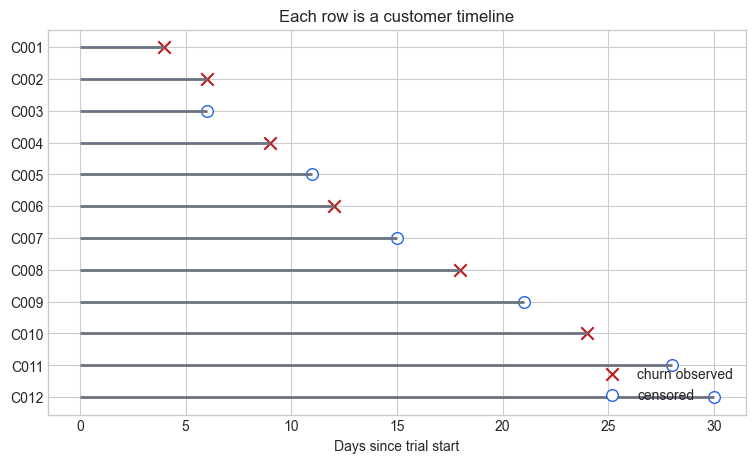

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

y_pos = np.arange(len(df))
ax.hlines(y=y_pos, xmin=0, xmax=df["days_since_trial_start"], color="#6B7280", linewidth=2)

events = df["churn_observed"].eq(1)
ax.scatter(df.loc[events, "days_since_trial_start"], y_pos[events], marker="x", s=80, color="#B91C1C", label="churn observed")
ax.scatter(df.loc[~events, "days_since_trial_start"], y_pos[~events], marker="o", s=70, facecolor="white", edgecolor="#2563EB", label="censored")

ax.set_yticks(y_pos)
ax.set_yticklabels(df["customer_id"])
ax.invert_yaxis()
ax.set_xlabel("Days since trial start")
ax.set_title("Each row is a customer timeline")
ax.legend(loc="lower right")
plt.show()

## Kaplan-Meier by hand

Kaplan-Meier is just careful bookkeeping over time.

At each event time:

1. Count how many customers were still at risk right before that time.
2. Count how many events happened at that time.
3. Multiply the previous survival probability by `1 - events / at_risk`.

Censored customers reduce the future risk set, but they do not create a downward step in the curve because the event was not observed.

In [4]:
event_times = sorted(df.loc[df["churn_observed"].eq(1), "days_since_trial_start"].unique())
rows = []
survival = 1.0

for t in event_times:
    at_risk = (df["days_since_trial_start"] >= t).sum()
    observed = ((df["days_since_trial_start"] == t) & df["churn_observed"].eq(1)).sum()
    censored = ((df["days_since_trial_start"] == t) & df["churn_observed"].eq(0)).sum()
    survival *= 1 - observed / at_risk
    rows.append(
        {
            "event_day": t,
            "at_risk_before_day": at_risk,
            "churn_events_on_day": observed,
            "censored_on_day": censored,
            "survival_after_day": survival,
        }
    )

manual_km = pd.DataFrame(rows)
manual_km

,event_day,at_risk_before_day,churn_events_on_day,censored_on_day,survival_after_day
0,4,12,1,0,0.916667
1,6,11,1,1,0.833333
2,9,9,1,0,0.740741
3,12,7,1,0,0.634921
4,18,5,1,0,0.507937
5,24,3,1,0,0.338624


Look at the day 6 row: one customer churned and one was censored on the same day, yet `at_risk_before_day` is 11, not 10. That is the standard convention: a customer censored at day 6 stays in the risk set for the day 6 event, because censoring is treated as happening just *after* any event at the same time. Their exit thins the risk set only from the next event time onward.

Median survival time: 24.0


,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.0,0,0,0,12,12
4.0,1,1,0,0,12
6.0,2,1,1,0,11
9.0,1,1,0,0,9
11.0,1,0,1,0,8
12.0,1,1,0,0,7
15.0,1,0,1,0,6
18.0,1,1,0,0,5
21.0,1,0,1,0,4


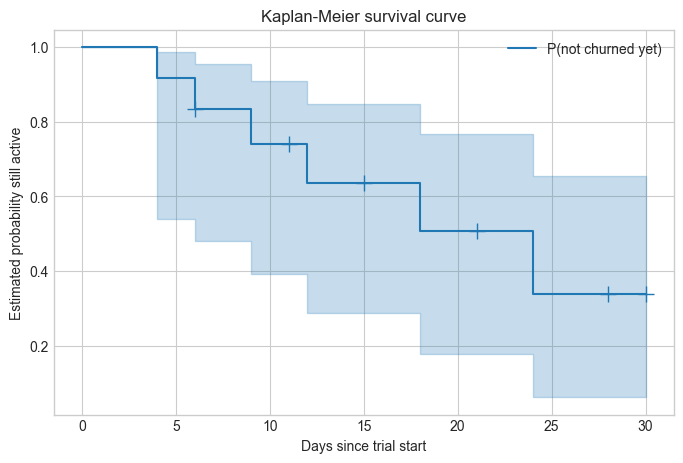

In [5]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(
    durations=df["days_since_trial_start"],
    event_observed=df["churn_observed"],
    label="P(not churned yet)",
)

print("Median survival time:", kmf.median_survival_time_)
display(kmf.event_table.head(10))

ax = kmf.plot_survival_function(figsize=(8, 5), ci_show=True, show_censors=True)
ax.set_title("Kaplan-Meier survival curve")
ax.set_xlabel("Days since trial start")
ax.set_ylabel("Estimated probability still active")
plt.show()

### Reading the median (and the ticks)

The **median survival time** is the smallest `t` where the curve reaches `S(t) <= 0.5` - the day by which half the customers are estimated to have churned. When a curve never crosses 0.5, lifelines returns `inf`. That is common in churn data, where most customers are still active at extraction, and it is an honest answer: the data cannot say when the halfway point comes.

Two notes on this tiny dataset:

- The 24-day median is fragile. `S(18) = 0.5079`, barely above 0.5. One extra churn around day 18 would move the median from 24 all the way to 18. With n = 12, report it with wide error bars in your voice, not just in the plot.
- The small ticks on the curve (`show_censors=True`) mark the customers who left the data without churning - in a notebook about censoring, the censored deserve to be visible.

In [6]:
horizons = [7, 14, 21, 30]
survival_at_horizons = kmf.survival_function_at_times(horizons).rename("survival_probability")
pd.DataFrame(
    {
        "day": horizons,
        "P(still active at day)": survival_at_horizons.values.round(3),
        "P(churned by day)": (1 - survival_at_horizons.values).round(3),
    }
)

,day,P(still active at day),P(churned by day)
0,7,0.833,0.167
1,14,0.635,0.365
2,21,0.508,0.492
3,30,0.339,0.661


One caution about the last row: `S(30) = 0.339` rests on a single customer still at risk after day 28. The confidence band widening toward the right edge of the plot is saying the same thing. Do not quote three-decimal tail probabilities that hang on a risk set of one.

## Why not just take the mean?

The introduction claimed that mishandling censored customers biases your answer. Here is that claim made concrete, using the two most common shortcuts:

1. **Drop the censored rows** and average the observed churn times.
2. **Keep every row** and treat each duration as final, censored or not.

In [7]:
print(f"Mean duration, censored rows dropped: {df.loc[df['churn_observed'].eq(1), 'days_since_trial_start'].mean():.1f} days")
print(f"Naive mean, censoring ignored:        {df['days_since_trial_start'].mean():.1f} days")
print(f"Kaplan-Meier median survival:         {kmf.median_survival_time_:.0f} days")

Mean duration, censored rows dropped: 12.2 days
Naive mean, censoring ignored:        15.3 days
Kaplan-Meier median survival:         24 days


Both shortcuts land at 12-15 days while Kaplan-Meier puts the median at 24: roughly half the truth. And the error is systematic, not noise. The censored rows are exactly the longest-lived customers - look back at the timeline plot, where the open circles cluster on the right. Dropping them deletes your best customers; keeping their durations as final pretends they churned the day you pulled the data. Either way, the estimate can only be dragged down.

## When to recommend survival analysis

Recommend survival analysis when the business question contains both an event and a clock.

Good use cases:

- Customer churn: time from signup to cancellation.
- Credit risk: time from loan origination to default.
- Product growth: time from signup to activation.
- Operations: time from installation to machine failure.
- Healthcare: time from treatment to relapse.

Be cautious when:

- You only know whether the event ever happened, not when.
- The event date is created by a vague business rule.
- Your features are measured after the prediction time.
- You plan to use censored rows as if they are true non-events.

The core discipline is simple: define the clock, define the event, and protect the model from the future.

One lens is still missing: the **hazard rate**, the instantaneous risk of churning right now given survival so far. It arrives in notebook 03, where it powers the Cox model.